# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

In [5]:
import pandas as pd

df = pd.read_csv("AB_NYC_2019.csv")
df.head(20)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


## EDA

Удаляем ненужные признаки: `id`, `name`, `host_id`, `host_name`, `last_review`.

In [6]:
drop_cols = ["id", "name", "host_id", "host_name", "last_review"]
df = df.drop(columns=drop_cols)
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


### Распределения признаков

Сначала таблица базовых статистик, затем гистограммы числовых признаков и bar plot для категориальных.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0
minimum_nights,48895.0,NaN,NaN,NaN,7.029962,20.51055,1.0,1.0,3.0,5.0,1250.0
number_of_reviews,48895.0,NaN,NaN,NaN,23.274466,44.550582,0.0,1.0,5.0,24.0,629.0
reviews_per_month,38843.0,NaN,NaN,NaN,1.373221,1.680442,0.01,0.19,0.72,2.02,58.5
calculated_host_listings_count,48895.0,NaN,NaN,NaN,7.143982,32.952519,1.0,1.0,1.0,2.0,327.0


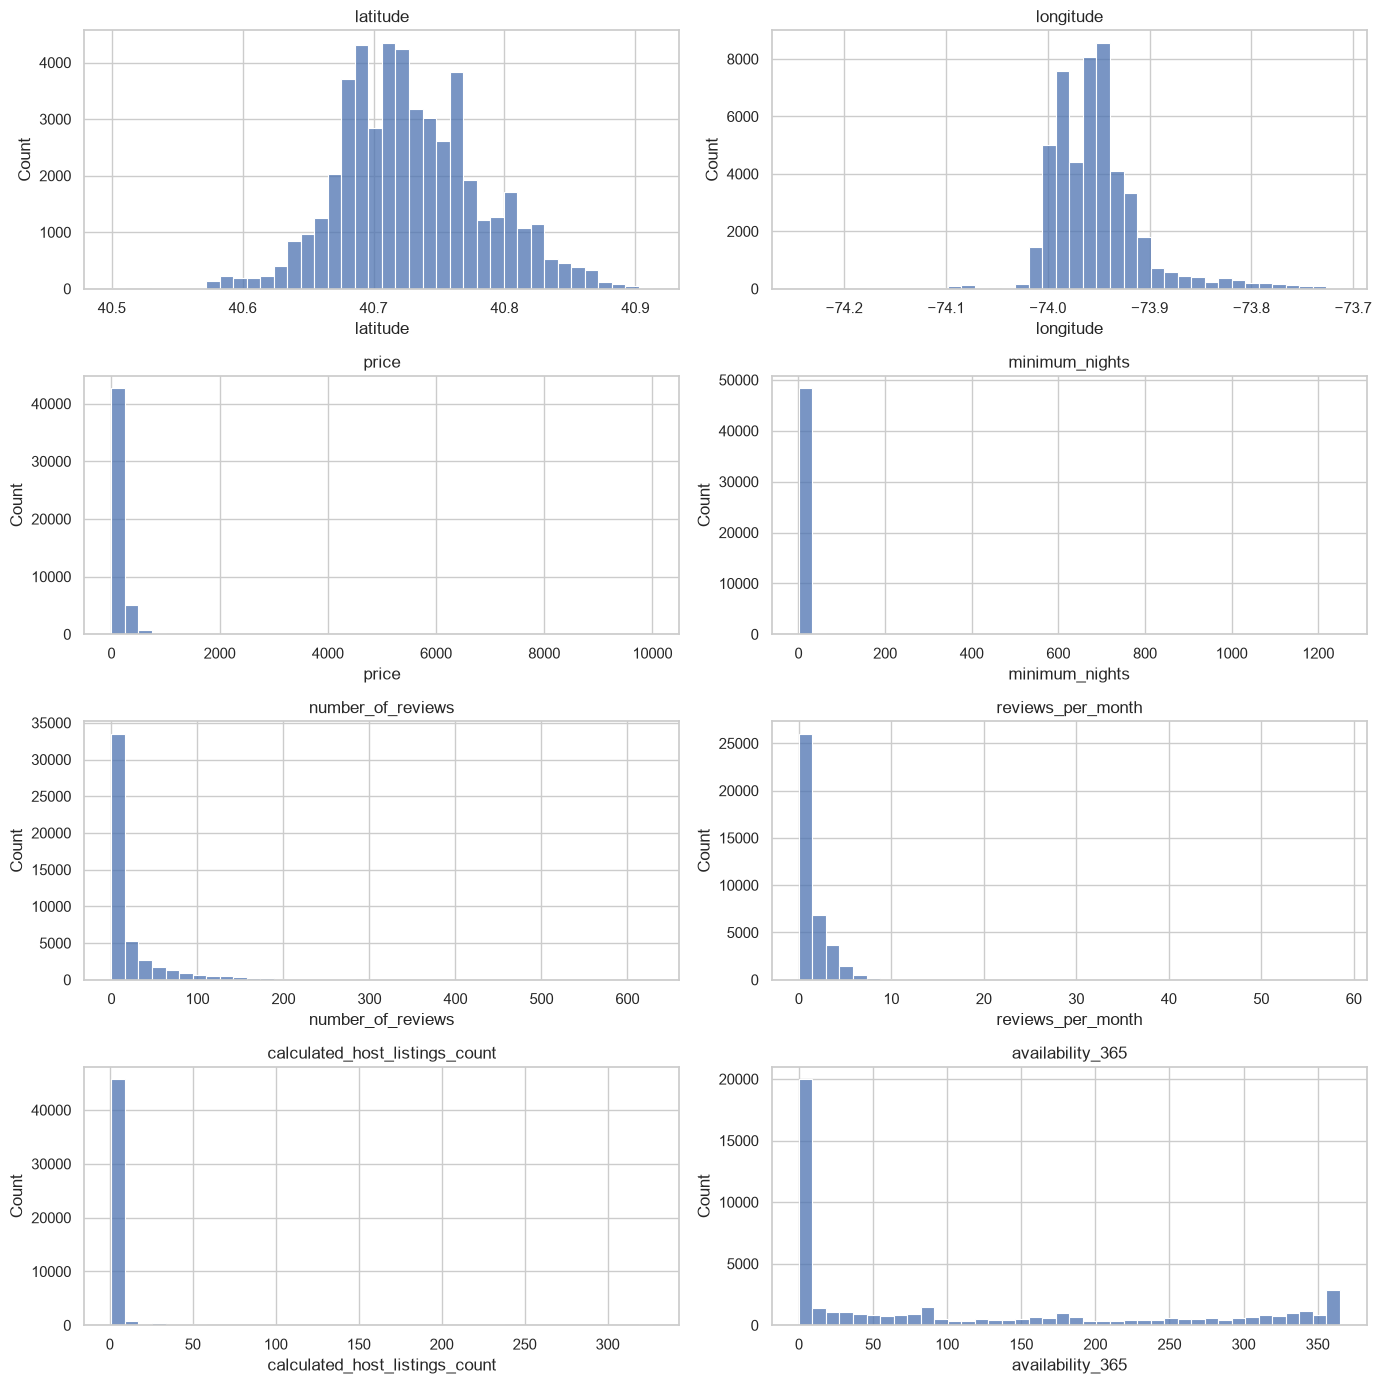

In [8]:
num_cols = [
    "latitude",
    "longitude",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
]

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.ravel()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), bins=40, kde=False, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

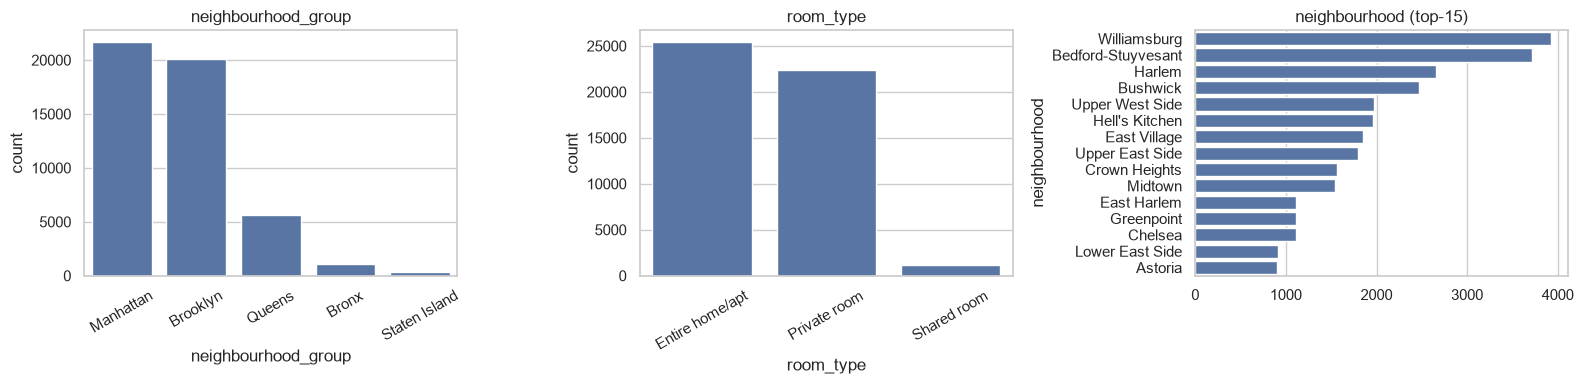

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df, x="neighbourhood_group", order=df["neighbourhood_group"].value_counts().index, ax=axes[0])
axes[0].set_title("neighbourhood_group")
axes[0].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="room_type", order=df["room_type"].value_counts().index, ax=axes[1])
axes[1].set_title("room_type")
axes[1].tick_params(axis="x", rotation=30)

top_neigh = df["neighbourhood"].value_counts().head(15)
sns.barplot(x=top_neigh.values, y=top_neigh.index, ax=axes[2])
axes[2].set_title("neighbourhood (top-15)")

plt.tight_layout()
plt.show()

### Матрица попарных корреляций

Считаем корреляцию Пирсона только по числовым признакам и рисуем heatmap.

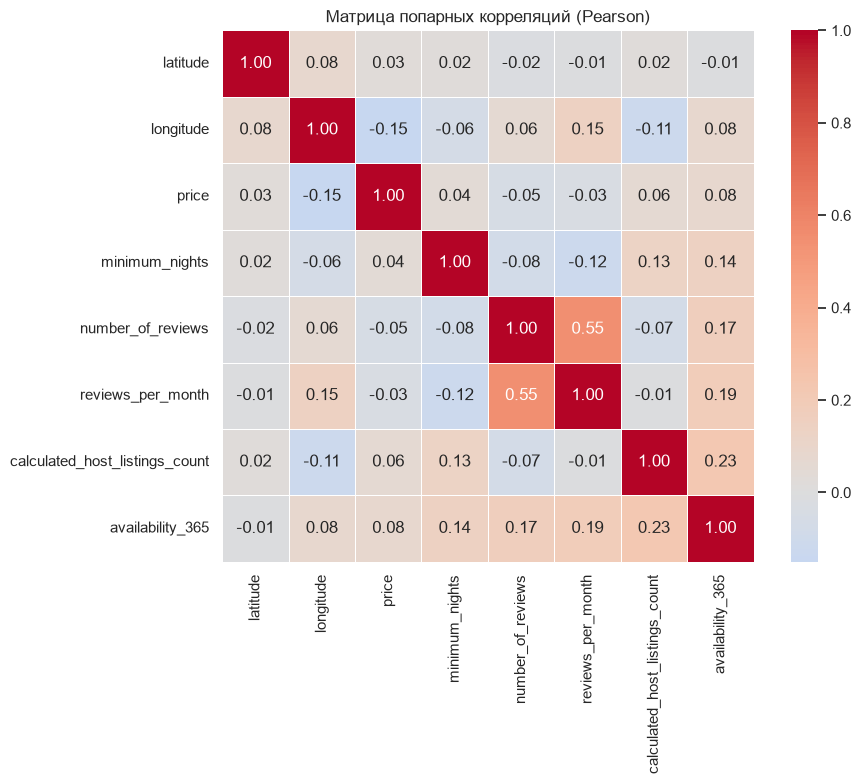

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
latitude,1.000000,0.084788,0.033939,0.024869,-0.015389,-0.010142,0.019517,-0.010983
longitude,0.084788,1.000000,-0.150019,-0.062747,0.059094,0.145948,-0.114713,0.082731
price,0.033939,-0.150019,1.000000,0.042799,-0.047954,-0.030608,0.057472,0.081829
minimum_nights,0.024869,-0.062747,0.042799,1.000000,-0.080116,-0.121702,0.127960,0.144303
number_of_reviews,-0.015389,0.059094,-0.047954,-0.080116,1.000000,0.549868,-0.072376,0.172028
reviews_per_month,-0.010142,0.145948,-0.030608,-0.121702,0.549868,1.000000,-0.009421,0.185791
calculated_host_listings_count,0.019517,-0.114713,0.057472,0.127960,-0.072376,-0.009421,1.000000,0.225701
availability_365,-0.010983,0.082731,0.081829,0.144303,0.172028,0.185791,0.225701,1.000000


In [10]:
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Матрица попарных корреляций (Pearson)")
plt.tight_layout()
plt.show()

corr

### Pair plots

Попарные зависимости числовых признаков. Берём случайную подвыборку (иначе на ~49k строк строится очень долго) и ключевые колонки.

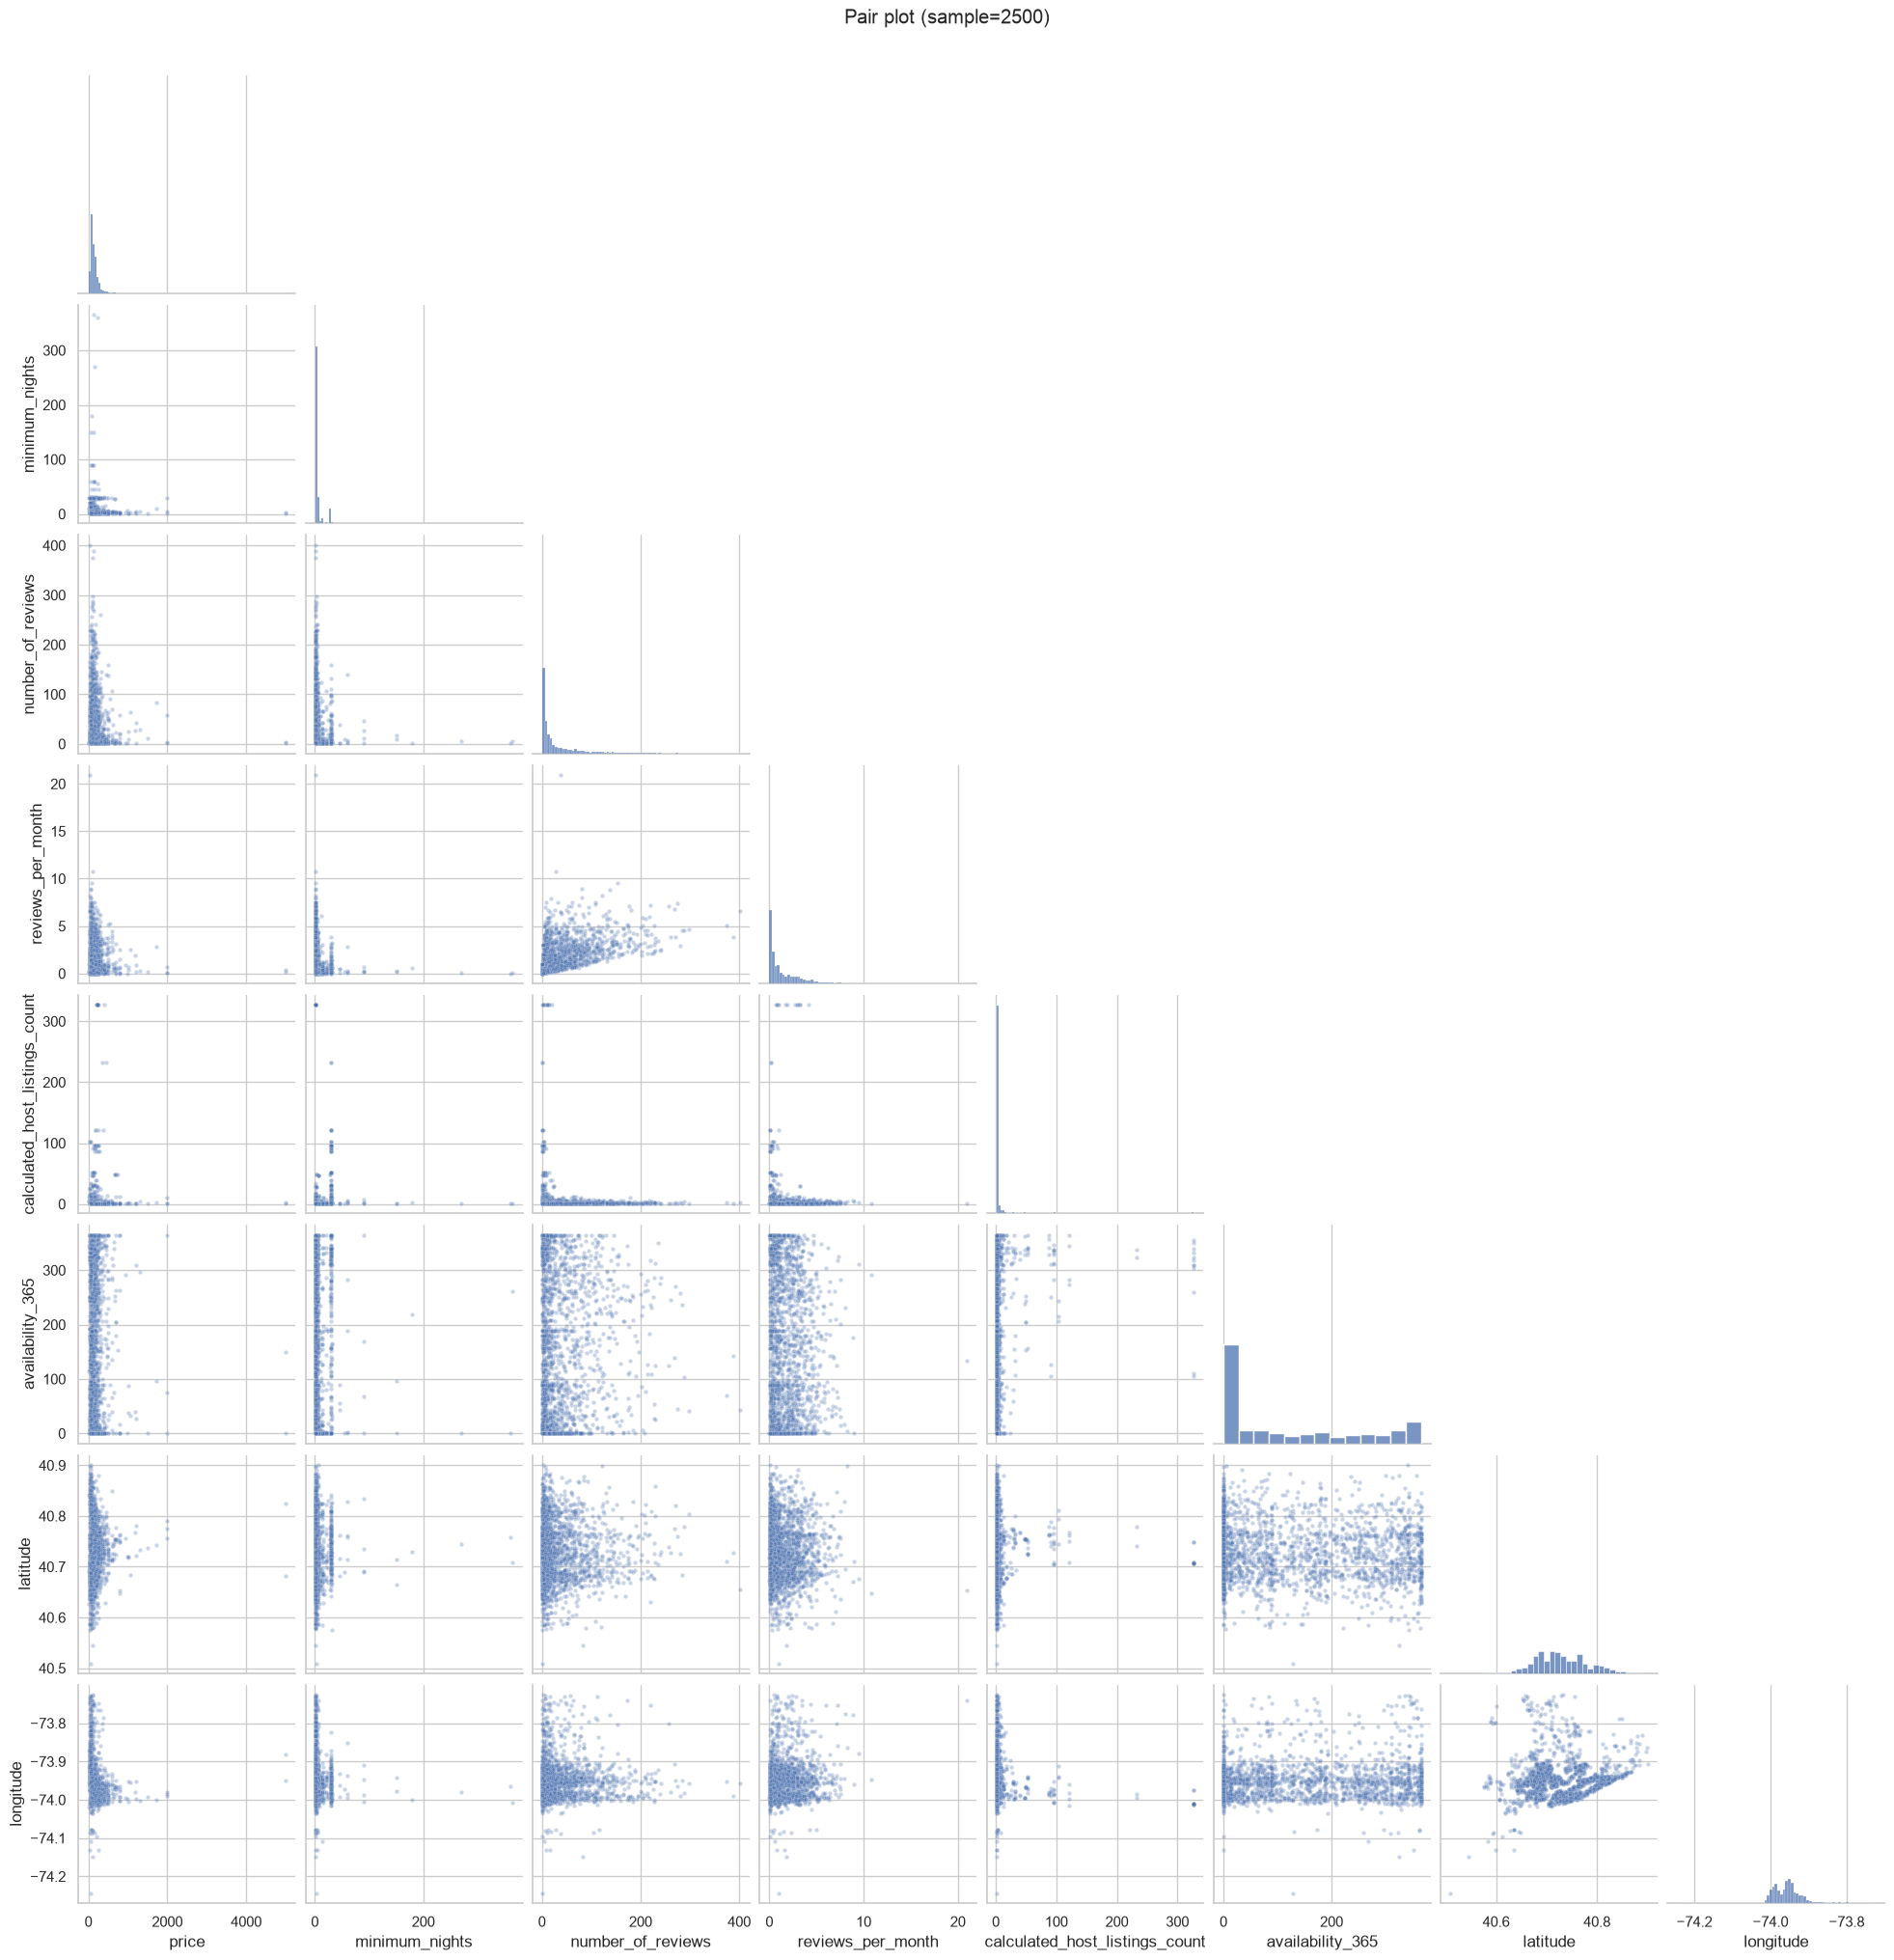

In [11]:
pair_cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "latitude",
    "longitude",
]

pair_df = (
    df[pair_cols]
    .dropna()
    .sample(n=2500, random_state=42)
)

sns.pairplot(pair_df, corner=True, plot_kws={"alpha": 0.3, "s": 10})
plt.suptitle("Pair plot (sample=2500)", y=1.02)
plt.show()

### Предобработка по результатам EDA

Выводы из анализа и что делаем:
1. **`reviews_per_month`** — ~10k NaN (нет отзывов) → заполняем `0`.
2. **`price == 0`** — невалидная цена для целевой переменной → удаляем строки.
3. **Выбросы `price`** — длинный хвост до 10000; 95% ≤ 355, 99% ≤ 799 → оставляем `price ≤ 500` (типичный порог для NYC Airbnb).
4. **Выбросы `minimum_nights`** — max 1250 при 99% ≤ 45 → ограничиваем сверху (`clip`) значением 365 (год).

In [12]:
print("До предобработки:", df.shape)
print("NaN в reviews_per_month:", df["reviews_per_month"].isna().sum())
print("price == 0:", (df["price"] == 0).sum())
print("price > 500:", (df["price"] > 500).sum())
print("minimum_nights > 365:", (df["minimum_nights"] > 365).sum())

# 1. Пропуски: нет отзывов → 0 отзывов в месяц
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# 2–3. Целевая переменная: убираем нулевые и экстремальные цены
df = df[(df["price"] > 0) & (df["price"] <= 500)].copy()

# 4. Аномалии minimum_nights: обрезаем сверху
df["minimum_nights"] = df["minimum_nights"].clip(upper=365)

print("\nПосле предобработки:", df.shape)
print("NaN всего:\n", df.isna().sum())
df.describe().T

До предобработки: (48895, 11)
NaN в reviews_per_month: 10052
price == 0: 11
price > 500: 1044
minimum_nights > 365: 14

После предобработки: (47840, 11)
NaN всего:
 neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
latitude,47840.0,40.728818,0.054777,40.49979,40.689830,40.72264,40.763250,40.91306
longitude,47840.0,-73.951663,0.046243,-74.24442,-73.982673,-73.95522,-73.935598,-73.71299
price,47840.0,131.560807,88.050752,10.00000,68.000000,101.00000,172.000000,500.00000
minimum_nights,47840.0,6.892559,17.314520,1.00000,1.000000,2.00000,5.000000,365.00000
number_of_reviews,47840.0,23.544147,44.821842,0.00000,1.000000,5.00000,24.000000,629.00000
reviews_per_month,47840.0,1.100069,1.604383,0.00000,0.040000,0.38000,1.610000,58.50000
calculated_host_listings_count,47840.0,7.077132,32.763333,1.00000,1.000000,1.00000,2.000000,327.00000
availability_365,47840.0,111.204536,130.981942,0.00000,0.000000,43.00000,221.000000,365.00000


## Часть 2. Preprocessing & Feature Engineering

### Сводка опробованных методик (тезисно)

| Техника | Результат |
|---|---|
| Baseline: dummies + LinearRegression | ориентир: R²≈0.46, MAE≈44, RMSE≈65 |
| Категории: без `neighbourhood` | хуже baseline — район важен |
| Категории: full OneHot `neighbourhood` | **помогло** vs без района |
| Категории: top-20 + Other | почти как full, меньше признаков |
| Категории: frequency encoding | почти не помогло |
| Аномалии: `price≤500` | разумный баланс |
| Аномалии: `price≤p95` | метрики выше, но выборка проще |
| Аномалии: без верхнего порога цены | сильно хуже |
| Аномалии: `log1p` признаков | небольшой плюс |
| Target: `log1p(price)` | частично (MAE↓, R²≈) |
| StandardScaler / RobustScaler | для OLS **без разницы** (ожидаемо) |
| FE: `dist_to_manhattan` и др. | небольшой плюс |

Подробная таблица с цифрами — в конце Части 2 (после всех экспериментов).

### Baseline

Простой пайплайн: `get_dummies` + `LinearRegression`. Split 70/30 фиксируем (`random_state=42`), чтобы сравнивать следующие техники на одинаковом тесте.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np


def eval_regression(y_true, y_pred):
    """R², MAE, RMSE в одной таблице."""
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
    }


# Журнал экспериментов: техника → метрики на test
results = {}

y = df["price"]
X = df.drop(columns=["price"])

# Категории → dummy (первая категория отбрасывается, чтобы избежать полной коллинеарности)
X_base = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.3, random_state=42
)

print("X shape after dummies:", X_base.shape)
print("train:", X_train.shape, "test:", X_test.shape)
X_train.head()

X shape after dummies: (47840, 231)
train: (33488, 231) test: (14352, 231)


,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,...,neighbourhood_Whitestone,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodside,room_type_Private room,room_type_Shared room
33549,40.85515,-73.93297,4,20,1.94,1,228,False,True,False,...,False,False,False,False,False,False,False,False,False,False
37225,40.67810,-73.91163,2,26,3.59,4,192,True,False,False,...,False,False,False,False,False,False,False,False,True,False
12104,40.73047,-73.98576,4,10,0.23,1,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
10871,40.83746,-73.92268,4,51,1.11,2,0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
33007,40.72918,-74.00482,1,40,3.09,10,247,False,True,False,...,False,False,False,False,False,False,False,False,True,False


In [14]:
model_base = LinearRegression()
model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)
metrics_base = eval_regression(y_test, y_pred_base)
results["baseline: dummies + LinearRegression"] = metrics_base

pd.DataFrame(results).T.round(4)

,R2,MAE,RMSE
baseline: dummies + LinearRegression,0.4572,44.0891,65.3622


### Категориальные признаки: сравнение кодировок

Сравниваем на одном и том же split (`test_size=0.3`, `random_state=42`):
1. **без `neighbourhood`** — только `neighbourhood_group` + `room_type` (OneHot/dummy);
2. **с полным OneHot `neighbourhood`** — как в baseline (~200 районов);
3. **top-20 + Other** — редкие районы схлопываем в одну категорию;
4. **frequency encoding** — вместо dummy частота района в train.

In [15]:
def run_linreg(X_feat, y_feat, name):
    """Обучить LinearRegression на том же split и записать метрики в results."""
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_feat, y_feat, test_size=0.3, random_state=42
    )
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    metrics = eval_regression(y_te, model.predict(X_te))
    results[name] = metrics
    print(f"{name}: features={X_feat.shape[1]}, R2={metrics['R2']:.4f}, MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}")
    return model


num_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
]

y_all = df["price"]

# 1) без neighbourhood
X_no_neigh = pd.get_dummies(
    df[num_features + ["neighbourhood_group", "room_type"]],
    drop_first=True,
)
run_linreg(X_no_neigh, y_all, "cats: group+room_type (no neighbourhood)")

# 2) полный OneHot neighbourhood (то же, что baseline)
X_full = pd.get_dummies(
    df[num_features + ["neighbourhood_group", "neighbourhood", "room_type"]],
    drop_first=True,
)
run_linreg(X_full, y_all, "cats: + full OneHot neighbourhood")

# 3) top-20 neighbourhood + Other
top20 = df["neighbourhood"].value_counts().head(20).index
df_top = df.copy()
df_top["neighbourhood_top"] = df_top["neighbourhood"].where(
    df_top["neighbourhood"].isin(top20), other="Other"
)
X_top = pd.get_dummies(
    df_top[num_features + ["neighbourhood_group", "neighbourhood_top", "room_type"]],
    drop_first=True,
)
run_linreg(X_top, y_all, "cats: neighbourhood top-20 + Other")

# 4) frequency encoding для neighbourhood (считаем частоты только на train)
idx_train, idx_test = train_test_split(
    df.index, test_size=0.3, random_state=42
)
freq = df.loc[idx_train, "neighbourhood"].value_counts(normalize=True)
X_freq = df[num_features + ["neighbourhood_group", "room_type"]].copy()
X_freq["neighbourhood_freq"] = df["neighbourhood"].map(freq).fillna(0)
X_freq = pd.get_dummies(X_freq, drop_first=True)

X_tr = X_freq.loc[idx_train]
X_te = X_freq.loc[idx_test]
y_tr = y_all.loc[idx_train]
y_te = y_all.loc[idx_test]
model_freq = LinearRegression().fit(X_tr, y_tr)
metrics_freq = eval_regression(y_te, model_freq.predict(X_te))
results["cats: neighbourhood frequency encoding"] = metrics_freq
print(
    f"cats: neighbourhood frequency encoding: features={X_freq.shape[1]}, "
    f"R2={metrics_freq['R2']:.4f}, MAE={metrics_freq['MAE']:.4f}, RMSE={metrics_freq['RMSE']:.4f}"
)

pd.DataFrame(results).T.round(4)

cats: group+room_type (no neighbourhood): features=13, R2=0.4141, MAE=46.2383, RMSE=67.9071
cats: + full OneHot neighbourhood: features=231, R2=0.4572, MAE=44.0891, RMSE=65.3622
cats: neighbourhood top-20 + Other: features=33, R2=0.4414, MAE=44.7471, RMSE=66.3067
cats: neighbourhood frequency encoding: features=14, R2=0.4157, MAE=46.1221, RMSE=67.8117


,R2,MAE,RMSE
baseline: dummies + LinearRegression,0.4572,44.0891,65.3622
cats: group+room_type (no neighbourhood),0.4141,46.2383,67.9071
cats: + full OneHot neighbourhood,0.4572,44.0891,65.3622
cats: neighbourhood top-20 + Other,0.4414,44.7471,66.3067
cats: neighbourhood frequency encoding,0.4157,46.1221,67.8117


### Аномалии: доработка предобработки

Идея — менять **по одной** настройке (без scaler). Кодирование фиксируем: full OneHot категорий + LinearRegression.

Важно: разные пороги по `price` меняют состав выборки, поэтому MAE/R² сравнимы скорее внутри логики «насколько модель хороша на этом срезе», а не как один абсолютный рейтинг.

Пробуем:
1. текущий вариант: `0 < price ≤ 500`, `minimum_nights` clip 365;
2. мягче: `price ≤ 1000`;
3. жёстче: `price ≤ 95-й перцентиль` (~355);
4. без верхнего порога по цене (только `price > 0`);
5. как (1), но `log1p` для хвостатых признаков (не target).

In [16]:
def load_raw_for_anomaly_exps():
    """Сырой датасет после drop ненужных колонок + fillna reviews (без фильтра price)."""
    raw = pd.read_csv("AB_NYC_2019.csv")
    raw = raw.drop(columns=["id", "name", "host_id", "host_name", "last_review"])
    raw["reviews_per_month"] = raw["reviews_per_month"].fillna(0)
    return raw


def prepare_xy(data, log_features=False):
    """X (dummies) и y из уже отфильтрованного data."""
    data = data.copy()
    if log_features:
        for col in [
            "minimum_nights",
            "number_of_reviews",
            "reviews_per_month",
            "calculated_host_listings_count",
        ]:
            data[col] = np.log1p(data[col])
    y_ = data["price"]
    X_ = pd.get_dummies(data.drop(columns=["price"]), drop_first=True)
    return X_, y_


def eval_anomaly_variant(data, name, log_features=False):
    X_, y_ = prepare_xy(data, log_features=log_features)
    run_linreg(X_, y_, name)
    print(f"  n_rows={len(data)}, price[min,max]=[{data['price'].min()}, {data['price'].max()}]")


raw0 = load_raw_for_anomaly_exps()

# 1) текущий порог
d1 = raw0[(raw0["price"] > 0) & (raw0["price"] <= 500)].copy()
d1["minimum_nights"] = d1["minimum_nights"].clip(upper=365)
eval_anomaly_variant(d1, "anomaly: price<=500 + clip nights")

# 2) мягче
d2 = raw0[(raw0["price"] > 0) & (raw0["price"] <= 1000)].copy()
d2["minimum_nights"] = d2["minimum_nights"].clip(upper=365)
eval_anomaly_variant(d2, "anomaly: price<=1000 + clip nights")

# 3) жёстче по 95-му перцентилю (считаем на price>0)
p95 = raw0.loc[raw0["price"] > 0, "price"].quantile(0.95)
d3 = raw0[(raw0["price"] > 0) & (raw0["price"] <= p95)].copy()
d3["minimum_nights"] = d3["minimum_nights"].clip(upper=365)
eval_anomaly_variant(d3, f"anomaly: price<=p95({p95:.0f}) + clip nights")

# 4) без верхнего порога
d4 = raw0[raw0["price"] > 0].copy()
d4["minimum_nights"] = d4["minimum_nights"].clip(upper=365)
eval_anomaly_variant(d4, "anomaly: price>0 only + clip nights")

# 5) как (1), но log1p хвостатых признаков
d5 = d1.copy()
eval_anomaly_variant(d5, "anomaly: price<=500 + log1p skewed features", log_features=True)

pd.DataFrame(results).T.round(4)

anomaly: price<=500 + clip nights: features=231, R2=0.4572, MAE=44.0891, RMSE=65.3622
  n_rows=47840, price[min,max]=[10, 500]
anomaly: price<=1000 + clip nights: features=233, R2=0.3625, MAE=54.6476, RMSE=94.1084
  n_rows=48645, price[min,max]=[10, 1000]
anomaly: price<=p95(355) + clip nights: features=231, R2=0.5081, MAE=36.3096, RMSE=50.6326
  n_rows=46443, price[min,max]=[10, 355]
anomaly: price>0 only + clip nights: features=233, R2=0.1463, MAE=69.6955, RMSE=180.5603
  n_rows=48884, price[min,max]=[10, 10000]
anomaly: price<=500 + log1p skewed features: features=231, R2=0.4676, MAE=43.8007, RMSE=64.7342
  n_rows=47840, price[min,max]=[10, 500]


,R2,MAE,RMSE
baseline: dummies + LinearRegression,0.4572,44.0891,65.3622
cats: group+room_type (no neighbourhood),0.4141,46.2383,67.9071
cats: + full OneHot neighbourhood,0.4572,44.0891,65.3622
cats: neighbourhood top-20 + Other,0.4414,44.7471,66.3067
cats: neighbourhood frequency encoding,0.4157,46.1221,67.8117
anomaly: price<=500 + clip nights,0.4572,44.0891,65.3622
anomaly: price<=1000 + clip nights,0.3625,54.6476,94.1084
anomaly: price<=p95(355) + clip nights,0.5081,36.3096,50.6326
anomaly: price>0 only + clip nights,0.1463,69.6955,180.5603
anomaly: price<=500 + log1p skewed features,0.4676,43.8007,64.7342


### Целевая переменная `price`

Смотрим распределение после фильтра (`price ≤ 500`). Затем учим модель на `y = log1p(price)`, на тесте делаем `expm1` и считаем R²/MAE/RMSE **в долларах** (чтобы сравнивать с baseline).

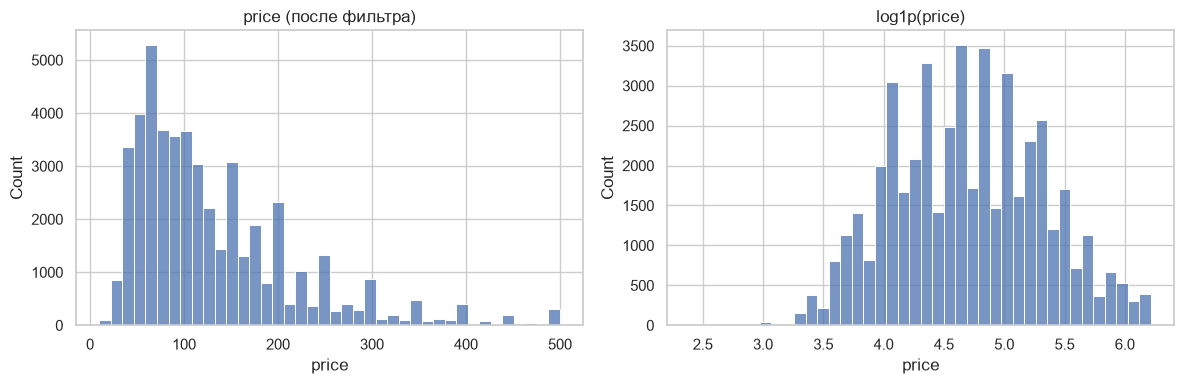

mean    131.560807
50%     101.000000
std      88.050752
min      10.000000
max     500.000000
Name: price, dtype: float64


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["price"], bins=40, ax=axes[0])
axes[0].set_title("price (после фильтра)")

sns.histplot(np.log1p(df["price"]), bins=40, ax=axes[1])
axes[1].set_title("log1p(price)")

plt.tight_layout()
plt.show()

print(df["price"].describe()[["mean", "50%", "std", "min", "max"]])

In [18]:
# Те же признаки, что у baseline (full dummies), тот же split
X_log = pd.get_dummies(df.drop(columns=["price"]), drop_first=True)
y_dollars = df["price"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_log, y_dollars, test_size=0.3, random_state=42
)

# Обучение в лог-пространстве
y_tr_log = np.log1p(y_tr)
model_log = LinearRegression()
model_log.fit(X_tr, y_tr_log)

# Прогноз → обратно в доллары
y_pred_log = np.expm1(model_log.predict(X_te))
# на всякий случай: отрицательные из-за шума округляем к 0
y_pred_log = np.clip(y_pred_log, 0, None)

metrics_log_target = eval_regression(y_te, y_pred_log)
results["target: log1p(price) + expm1 on test"] = metrics_log_target

print(
    f"log-target: R2={metrics_log_target['R2']:.4f}, "
    f"MAE={metrics_log_target['MAE']:.4f}, RMSE={metrics_log_target['RMSE']:.4f}"
)
pd.DataFrame(results).T.round(4)

log-target: R2=0.4439, MAE=41.5703, RMSE=66.1557


,R2,MAE,RMSE
baseline: dummies + LinearRegression,0.4572,44.0891,65.3622
cats: group+room_type (no neighbourhood),0.4141,46.2383,67.9071
cats: + full OneHot neighbourhood,0.4572,44.0891,65.3622
cats: neighbourhood top-20 + Other,0.4414,44.7471,66.3067
cats: neighbourhood frequency encoding,0.4157,46.1221,67.8117
anomaly: price<=500 + clip nights,0.4572,44.0891,65.3622
anomaly: price<=1000 + clip nights,0.3625,54.6476,94.1084
anomaly: price<=p95(355) + clip nights,0.5081,36.3096,50.6326
anomaly: price>0 only + clip nights,0.1463,69.6955,180.5603
anomaly: price<=500 + log1p skewed features,0.4676,43.8007,64.7342


### Шкалирование числовых признаков

Сравниваем на одном split и full OneHot:
- без scaler;
- `StandardScaler` (mean/std) — fit **только на train**;
- `RobustScaler` (median/IQR) — устойчивее к выбросам.

Скейлим только непрерывные колонки; dummy (0/1) не трогаем.

In [19]:
from sklearn.preprocessing import StandardScaler, RobustScaler

num_cols_scale = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
]

X_sc = pd.get_dummies(df.drop(columns=["price"]), drop_first=True)
y_sc = df["price"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sc, y_sc, test_size=0.3, random_state=42
)


def eval_with_scaler(scaler, name):
    X_tr_s = X_tr.copy()
    X_te_s = X_te.copy()

    if scaler is not None:
        X_tr_s[num_cols_scale] = scaler.fit_transform(X_tr[num_cols_scale])
        X_te_s[num_cols_scale] = scaler.transform(X_te[num_cols_scale])

    model = LinearRegression()
    model.fit(X_tr_s, y_tr)
    metrics = eval_regression(y_te, model.predict(X_te_s))
    results[name] = metrics
    print(
        f"{name}: R2={metrics['R2']:.4f}, MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}"
    )


eval_with_scaler(None, "scale: none (numeric as-is)")
eval_with_scaler(StandardScaler(), "scale: StandardScaler (numeric only)")
eval_with_scaler(RobustScaler(), "scale: RobustScaler (numeric only)")

pd.DataFrame(results).T.round(4)

scale: none (numeric as-is): R2=0.4572, MAE=44.0891, RMSE=65.3622
scale: StandardScaler (numeric only): R2=0.4572, MAE=44.0891, RMSE=65.3622
scale: RobustScaler (numeric only): R2=0.4572, MAE=44.0891, RMSE=65.3622


,R2,MAE,RMSE
baseline: dummies + LinearRegression,0.4572,44.0891,65.3622
cats: group+room_type (no neighbourhood),0.4141,46.2383,67.9071
cats: + full OneHot neighbourhood,0.4572,44.0891,65.3622
cats: neighbourhood top-20 + Other,0.4414,44.7471,66.3067
cats: neighbourhood frequency encoding,0.4157,46.1221,67.8117
anomaly: price<=500 + clip nights,0.4572,44.0891,65.3622
anomaly: price<=1000 + clip nights,0.3625,54.6476,94.1084
anomaly: price<=p95(355) + clip nights,0.5081,36.3096,50.6326
anomaly: price>0 only + clip nights,0.1463,69.6955,180.5603
anomaly: price<=500 + log1p skewed features,0.4676,43.8007,64.7342


### Feature engineering

Новые признаки (поверх текущего `df` после предобработки):
- **`dist_to_manhattan`** — евклидово расстояние по lat/lon до центра Манхэттена (~Times Square: 40.7580, −73.9855);
- **`availability_frac`** — доля дней в году, когда жильё доступно;
- **`always_available`** — бинарный флаг `availability_365 == 365`;
- **`has_reviews`** — был ли хотя бы один отзыв.

Сравниваем: baseline-признаки / + только distance / + все новые / distance **вместо** lat/lon.

In [20]:
MANHATTAN_LAT, MANHATTAN_LON = 40.7580, -73.9855

df_fe = df.copy()
df_fe["dist_to_manhattan"] = np.sqrt(
    (df_fe["latitude"] - MANHATTAN_LAT) ** 2
    + (df_fe["longitude"] - MANHATTAN_LON) ** 2
)
df_fe["availability_frac"] = df_fe["availability_365"] / 365.0
df_fe["always_available"] = (df_fe["availability_365"] == 365).astype(int)
df_fe["has_reviews"] = (df_fe["number_of_reviews"] > 0).astype(int)

print("Новые признаки (фрагмент):")
display(
    df_fe[
        [
            "latitude",
            "longitude",
            "dist_to_manhattan",
            "availability_frac",
            "always_available",
            "has_reviews",
            "price",
        ]
    ].head()
)

# корреляция новых признаков с ценой
print("\nКорреляция с price:")
print(
    df_fe[
        ["dist_to_manhattan", "availability_frac", "always_available", "has_reviews", "price"]
    ]
    .corr()["price"]
    .drop("price")
    .round(3)
)


def fe_matrix(data, cols_extra=None, drop_latlon=False):
    data = data.copy()
    drop_cols = ["price"]
    if drop_latlon:
        drop_cols += ["latitude", "longitude"]
    use = data.drop(columns=drop_cols)
    if cols_extra is not None:
        # cols_extra уже в data; просто явно ничего не режем
        pass
    return pd.get_dummies(use, drop_first=True), data["price"]


# 1) baseline без FE (контроль)
X0, y0 = fe_matrix(df)
run_linreg(X0, y0, "FE: baseline (no new features)")

# 2) только dist_to_manhattan
X1, y1 = fe_matrix(df_fe.drop(columns=["availability_frac", "always_available", "has_reviews"]))
run_linreg(X1, y1, "FE: + dist_to_manhattan")

# 3) все новые признаки
X2, y2 = fe_matrix(df_fe)
run_linreg(X2, y2, "FE: + all new features")

# 4) dist вместо lat/lon (+ остальные новые)
X3, y3 = fe_matrix(df_fe, drop_latlon=True)
run_linreg(X3, y3, "FE: dist instead of lat/lon + extras")

pd.DataFrame(results).T.round(4)

Новые признаки (фрагмент):


,latitude,longitude,dist_to_manhattan,availability_frac,always_available,has_reviews,price
0,40.64749,-73.97237,0.111287,1.000000,1,1,149
1,40.75362,-73.98377,0.004709,0.972603,0,1,225
2,40.80902,-73.94190,0.067112,1.000000,1,0,150
3,40.68514,-73.95976,0.077273,0.531507,0,1,89
4,40.79851,-73.94399,0.058001,0.000000,0,1,80



Корреляция с price:
dist_to_manhattan   -0.355
availability_frac    0.095
always_available     0.022
has_reviews         -0.079
Name: price, dtype: float64
FE: baseline (no new features): features=231, R2=0.4572, MAE=44.0891, RMSE=65.3622
FE: + dist_to_manhattan: features=232, R2=0.4580, MAE=44.0258, RMSE=65.3125
FE: + all new features: features=235, R2=0.4628, MAE=43.8807, RMSE=65.0218
FE: dist instead of lat/lon + extras: features=233, R2=0.4627, MAE=43.8841, RMSE=65.0271


,R2,MAE,RMSE
baseline: dummies + LinearRegression,0.4572,44.0891,65.3622
cats: group+room_type (no neighbourhood),0.4141,46.2383,67.9071
cats: + full OneHot neighbourhood,0.4572,44.0891,65.3622
cats: neighbourhood top-20 + Other,0.4414,44.7471,66.3067
cats: neighbourhood frequency encoding,0.4157,46.1221,67.8117
anomaly: price<=500 + clip nights,0.4572,44.0891,65.3622
anomaly: price<=1000 + clip nights,0.3625,54.6476,94.1084
anomaly: price<=p95(355) + clip nights,0.5081,36.3096,50.6326
anomaly: price>0 only + clip nights,0.1463,69.6955,180.5603
anomaly: price<=500 + log1p skewed features,0.4676,43.8007,64.7342


### Сводка экспериментов (конец Части 2)

Сравниваем каждую технику с baseline `baseline: dummies + LinearRegression` (или первой записью baseline в `results`).

Критерий «помогло»:
- **да** — R² выше и хотя бы одна из MAE/RMSE ниже;
- **частично** — улучшилась ровно одна сторона (R²↑ или ошибки↓), остальное нет;
- **нет** — иначе;
- **≈** — метрики совпадают с baseline (типично для scaler при OLS).

In [22]:
summary = pd.DataFrame(results).T

# якорь для сравнения
base_key = None
for key in summary.index:
    if "baseline" in key.lower() and "dummies" in key.lower():
        base_key = key
        break
if base_key is None:
    base_key = summary.index[0]

base = summary.loc[base_key]


def verdict_row(row):
    r2_up = row["R2"] > base["R2"] + 1e-4
    r2_down = row["R2"] < base["R2"] - 1e-4
    mae_down = row["MAE"] < base["MAE"] - 1e-4
    rmse_down = row["RMSE"] < base["RMSE"] - 1e-4
    same = (
        abs(row["R2"] - base["R2"]) < 1e-4
        and abs(row["MAE"] - base["MAE"]) < 1e-4
        and abs(row["RMSE"] - base["RMSE"]) < 1e-4
    )
    if same:
        return "≈ как baseline"
    better_fit = r2_up
    better_err = mae_down or rmse_down
    worse_fit = r2_down
    worse_err = (row["MAE"] > base["MAE"] + 1e-4) or (row["RMSE"] > base["RMSE"] + 1e-4)
    if better_fit and better_err:
        return "помогло"
    if (better_fit and not worse_err) or (better_err and not worse_fit):
        return "частично"
    if worse_fit or worse_err:
        return "не помогло"
    return "частично"


summary = summary.copy()
summary["ΔR2"] = (summary["R2"] - base["R2"]).round(4)
summary["ΔMAE"] = (summary["MAE"] - base["MAE"]).round(4)
summary["ΔRMSE"] = (summary["RMSE"] - base["RMSE"]).round(4)
summary["вердикт vs baseline"] = summary.apply(verdict_row, axis=1)

# baseline всегда помечаем отдельно
summary.loc[base_key, "вердикт vs baseline"] = "baseline (ориентир)"

summary_view = summary[["R2", "MAE", "RMSE", "ΔR2", "ΔMAE", "ΔRMSE", "вердикт vs baseline"]].round(4)
summary_view = summary_view.sort_values("R2", ascending=False)

print(f"Сравнение относительно: {base_key}")
summary_view

Сравнение относительно: baseline: dummies + LinearRegression


,R2,MAE,RMSE,ΔR2,ΔMAE,ΔRMSE,вердикт vs baseline
anomaly: price<=p95(355) + clip nights,0.5081,36.3096,50.6326,0.0509,-7.7795,-14.7296,помогло
anomaly: price<=500 + log1p skewed features,0.4676,43.8007,64.7342,0.0104,-0.2884,-0.6280,помогло
FE: + all new features,0.4628,43.8807,65.0218,0.0056,-0.2084,-0.3404,помогло
FE: dist instead of lat/lon + extras,0.4627,43.8841,65.0271,0.0056,-0.2049,-0.3351,помогло
FE: + dist_to_manhattan,0.4580,44.0258,65.3125,0.0008,-0.0633,-0.0497,помогло
anomaly: price<=500 + clip nights,0.4572,44.0891,65.3622,0.0000,0.0000,0.0000,≈ как baseline
scale: none (numeric as-is),0.4572,44.0891,65.3622,0.0000,0.0000,0.0000,≈ как baseline
scale: StandardScaler (numeric only),0.4572,44.0891,65.3622,0.0000,0.0000,-0.0000,≈ как baseline
scale: RobustScaler (numeric only),0.4572,44.0891,65.3622,0.0000,0.0000,-0.0000,≈ как baseline
FE: baseline (no new features),0.4572,44.0891,65.3622,0.0000,0.0000,0.0000,≈ как baseline


## Часть 3. Моделирование

### 0. Финальный датасет

Фиксируем пайплайн по итогам Части 2:
- предобработка: `0 < price ≤ 500`, `minimum_nights` clip 365, `reviews_per_month` fillna 0;
- FE: `dist_to_manhattan`, `availability_frac`, `always_available`, `has_reviews`;
- категории: full OneHot (`get_dummies`, `drop_first=True`);
- split 70/30, `random_state=42`;
- `RobustScaler` только на непрерывные числовые (fit на train).

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# --- собираем финальный df заново (чтобы Часть 3 не зависела от порядка ячеек) ---
df_final = pd.read_csv("AB_NYC_2019.csv")
df_final = df_final.drop(columns=["id", "name", "host_id", "host_name", "last_review"])
df_final["reviews_per_month"] = df_final["reviews_per_month"].fillna(0)
df_final = df_final[(df_final["price"] > 0) & (df_final["price"] <= 500)].copy()
df_final["minimum_nights"] = df_final["minimum_nights"].clip(upper=365)

MANHATTAN_LAT, MANHATTAN_LON = 40.7580, -73.9855
df_final["dist_to_manhattan"] = np.sqrt(
    (df_final["latitude"] - MANHATTAN_LAT) ** 2
    + (df_final["longitude"] - MANHATTAN_LON) ** 2
)
df_final["availability_frac"] = df_final["availability_365"] / 365.0
df_final["always_available"] = (df_final["availability_365"] == 365).astype(int)
df_final["has_reviews"] = (df_final["number_of_reviews"] > 0).astype(int)

y_final = df_final["price"]
X_final = pd.get_dummies(df_final.drop(columns=["price"]), drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.3, random_state=42
)

# непрерывные для scaler (бинарные FE не трогаем)
num_cols_final = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "dist_to_manhattan",
    "availability_frac",
]

scaler_final = RobustScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[num_cols_final] = scaler_final.fit_transform(X_train[num_cols_final])
X_test[num_cols_final] = scaler_final.transform(X_test[num_cols_final])

feature_names = list(X_train.columns)

print("df_final:", df_final.shape)
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train mean/std:", round(y_train.mean(), 2), round(y_train.std(), 2))
print("число признаков:", len(feature_names))
X_train.head()

df_final: (47840, 15)
X_train: (33488, 235) X_test: (14352, 235)
y_train mean/std: 131.18 87.76
число признаков: 235


,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,dist_to_manhattan,availability_frac,always_available,...,neighbourhood_Whitestone,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodside,room_type_Private room,room_type_Shared room
33549,1.808371,0.471963,0.50,0.652174,1.006452,0.0,0.845455,0.818985,0.845455,0,...,False,False,False,False,False,False,False,False,False,False
37225,-0.607293,0.925234,0.00,0.913043,2.070968,3.0,0.681818,0.789024,0.681818,0,...,False,False,False,False,False,False,False,False,True,False
12104,0.107242,-0.649320,0.50,0.217391,-0.096774,0.0,-0.190909,-0.707823,-0.190909,0,...,False,False,False,False,False,False,False,False,False,False
10871,1.567009,0.690527,0.50,2.000000,0.470968,1.0,-0.190909,0.650496,-0.190909,0,...,False,False,False,False,False,False,False,False,True,False
33007,0.089641,-1.054163,-0.25,1.521739,1.748387,9.0,0.931818,-0.575873,0.931818,0,...,False,False,False,False,False,False,False,False,True,False


### 1. Отложенный тест (30%)

По заданию: 30% данных — на тестирование. Split уже сделан при сборке финального датасета (`random_state=42`); ниже явно фиксируем размеры.

In [24]:
n_total = len(X_train) + len(X_test)
print(f"Всего объектов:     {n_total}")
print(f"Train (70%):        {X_train.shape[0]} строк, {X_train.shape[1]} признаков")
print(f"Test  (30%):        {X_test.shape[0]} строк, {X_test.shape[1]} признаков")
print(f"Доля теста:         {len(X_test) / n_total:.1%}")
print(f"random_state:       42")

pd.DataFrame(
    {
        "split": ["train", "test"],
        "n_rows": [X_train.shape[0], X_test.shape[0]],
        "n_features": [X_train.shape[1], X_test.shape[1]],
        "y_mean": [y_train.mean(), y_test.mean()],
        "y_std": [y_train.std(), y_test.std()],
    }
).round(2)

Всего объектов:     47840
Train (70%):        33488 строк, 235 признаков
Test  (30%):        14352 строк, 235 признаков
Доля теста:         30.0%
random_state:       42


,split,n_rows,n_features,y_mean,y_std
0,train,33488,235,131.18,87.76
1,test,14352,235,132.46,88.72


### 2. Четыре модели

Обучаем **только на train**. У `RidgeCV` / `LassoCV` / `ElasticNetCV` подбор `alpha` (и `l1_ratio` у ElasticNet) идёт через CV внутри train — `X_test` до финальной оценки не используем.

In [25]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV

# сетки для CV (только train)
alphas = np.logspace(-3, 3, 30)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]

models = {
    "LinearRegression": LinearRegression(),
    "RidgeCV": RidgeCV(alphas=alphas, cv=5),
    "LassoCV": LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42, n_jobs=-1),
    "ElasticNetCV": ElasticNetCV(
        alphas=alphas,
        l1_ratio=l1_ratios,
        cv=5,
        max_iter=10000,
        random_state=42,
        n_jobs=-1,
    ),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    extra = ""
    if hasattr(model, "alpha_"):
        extra = f", alpha_={model.alpha_:.4g}"
    if hasattr(model, "l1_ratio_"):
        extra += f", l1_ratio_={model.l1_ratio_:.4g}"
    if hasattr(model, "coef_"):
        n_zero = int(np.sum(np.isclose(model.coef_, 0)))
        extra += f", нулевых coef={n_zero}/{len(model.coef_)}"
    print(f"fitted: {name}{extra}")

print("\nМодели готовы:", list(models.keys()))

fitted: LinearRegression, нулевых coef=2/235
fitted: RidgeCV, alpha_=3.29, нулевых coef=2/235
fitted: LassoCV, alpha_=0.002593, нулевых coef=47/235
fitted: ElasticNetCV, alpha_=0.001, l1_ratio_=0.9, нулевых coef=18/235

Модели готовы: ['LinearRegression', 'RidgeCV', 'LassoCV', 'ElasticNetCV']


### 3. Метрики качества на test

Считаем R², MAE, RMSE на отложенных 30% для каждой из четырёх моделей.

In [26]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


def eval_regression(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
    }


results_part3 = {}
preds_part3 = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    preds_part3[name] = y_pred
    results_part3[name] = eval_regression(y_test, y_pred)

metrics_part3 = pd.DataFrame(results_part3).T.round(4)
metrics_part3 = metrics_part3.sort_values("R2", ascending=False)
metrics_part3

,R2,MAE,RMSE
RidgeCV,0.4630,43.8268,65.0117
LassoCV,0.4630,43.8299,65.0134
ElasticNetCV,0.4629,43.8213,65.0147
LinearRegression,0.4628,43.8807,65.0218


### 4. Важность признаков

Смотрим `|coef_|` (топ-20). Для Lasso/ElasticNet дополнительно — сколько коэффициентов обнулилось (отбор признаков). В конце — пересечение топ-признаков у всех моделей.

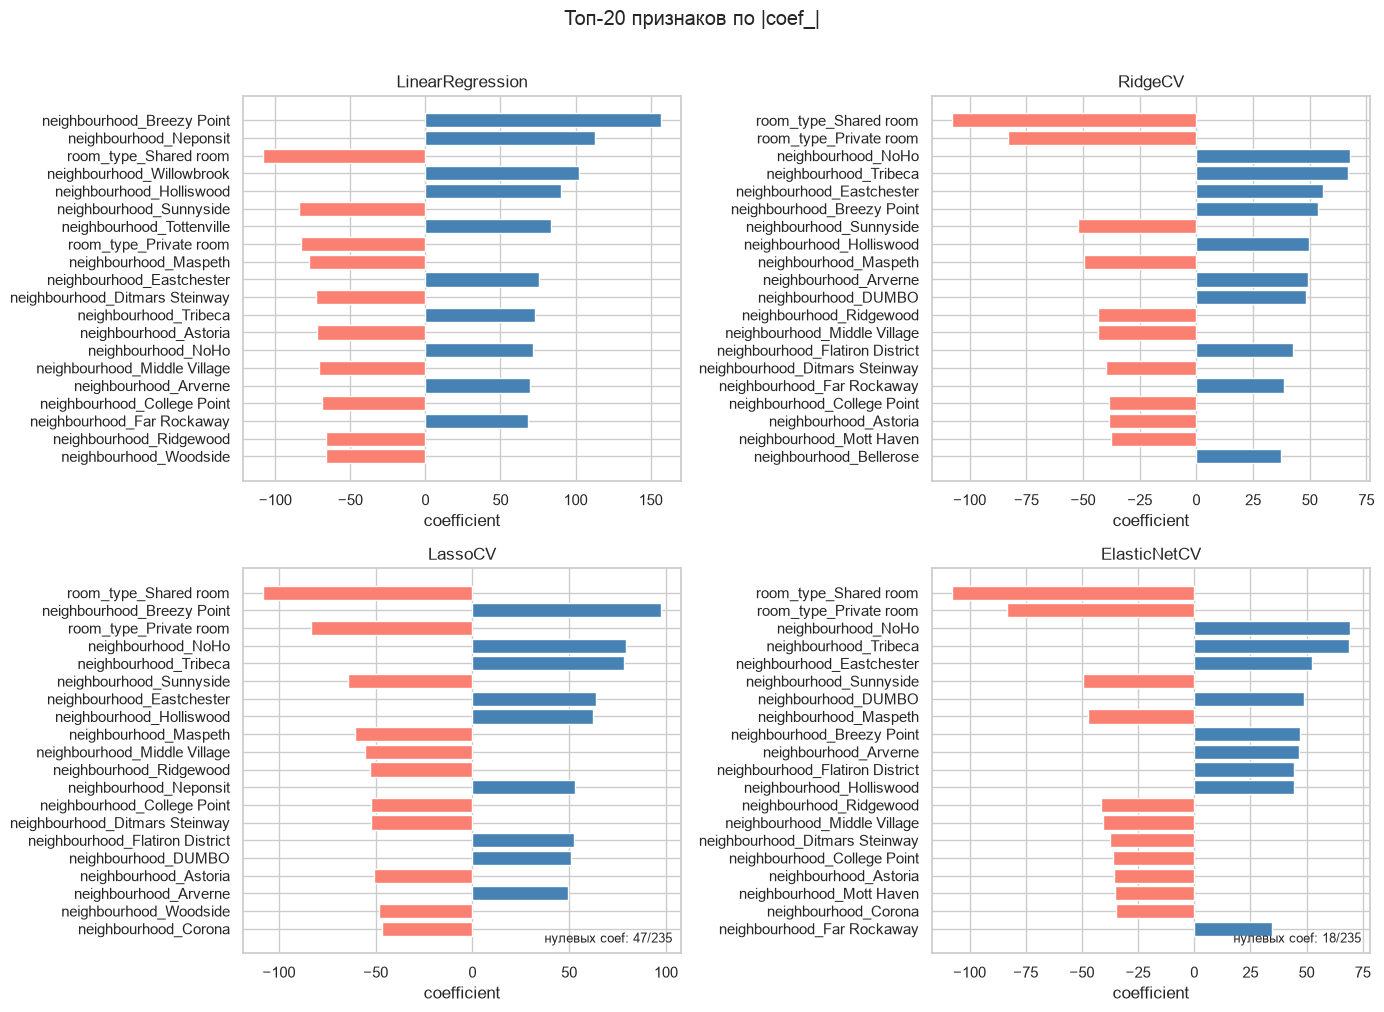

LassoCV: нулевых коэффициентов = 47 из 235 (20.0%)
ElasticNetCV: нулевых коэффициентов = 18 из 235 (7.7%)

Признаки, попавшие в топ-20 у ВСЕХ моделей (15):
['neighbourhood_Arverne', 'neighbourhood_Astoria', 'neighbourhood_Breezy Point', 'neighbourhood_College Point', 'neighbourhood_Ditmars Steinway', 'neighbourhood_Eastchester', 'neighbourhood_Holliswood', 'neighbourhood_Maspeth', 'neighbourhood_Middle Village', 'neighbourhood_NoHo', 'neighbourhood_Ridgewood', 'neighbourhood_Sunnyside', 'neighbourhood_Tribeca', 'room_type_Private room', 'room_type_Shared room']

Как часто признак в топ-20 (из 4 моделей):


,n_models
neighbourhood_Middle Village,4
neighbourhood_Maspeth,4
neighbourhood_Ditmars Steinway,4
neighbourhood_Astoria,4
neighbourhood_NoHo,4
neighbourhood_Holliswood,4
neighbourhood_College Point,4
neighbourhood_Ridgewood,4
neighbourhood_Eastchester,4
neighbourhood_Breezy Point,4


In [27]:
import matplotlib.pyplot as plt


def coef_importance(model, feature_names, top_n=20):
    coefs = pd.Series(model.coef_, index=feature_names)
    abs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)
    return abs_sorted.head(top_n), coefs


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

top_sets = {}

for ax, (name, model) in zip(axes, models.items()):
    top, coefs = coef_importance(model, feature_names, top_n=20)
    top_sets[name] = set(top.index)

    colors = ["steelblue" if v >= 0 else "salmon" for v in top.values]
    ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
    ax.set_title(name)
    ax.set_xlabel("coefficient")

    n_zero = int(np.sum(np.isclose(coefs, 0)))
    if name in ("LassoCV", "ElasticNetCV"):
        ax.text(
            0.98,
            0.02,
            f"нулевых coef: {n_zero}/{len(coefs)}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
        )

plt.suptitle("Топ-20 признаков по |coef_|", y=1.01)
plt.tight_layout()
plt.show()

# сколько нулей у регуляризованных L1-моделей
for name in ["LassoCV", "ElasticNetCV"]:
    coefs = pd.Series(models[name].coef_, index=feature_names)
    n_zero = int(np.sum(np.isclose(coefs, 0)))
    print(f"{name}: нулевых коэффициентов = {n_zero} из {len(coefs)} ({n_zero/len(coefs):.1%})")

# общие топ-признаки
common_top = set.intersection(*top_sets.values())
print(f"\nПризнаки, попавшие в топ-20 у ВСЕХ моделей ({len(common_top)}):")
print(sorted(common_top) if common_top else "(пустые пересечение — смотрим частые)")

# признаки, которые часто в топе (≥3 моделей)
from collections import Counter

freq = Counter()
for s in top_sets.values():
    freq.update(s)

frequent = pd.Series(freq).sort_values(ascending=False)
print("\nКак часто признак в топ-20 (из 4 моделей):")
frequent.head(15).to_frame("n_models")

### 5. Выводы

**Кто лучше по метрикам (test)**  
На финальном пайплайне все четыре модели очень близки: R² ≈ **0.463**, MAE ≈ **$44**, RMSE ≈ **$65**. Чуть впереди обычно **RidgeCV** (и рядом Lasso/ElasticNet); обычная `LinearRegression` почти не отстаёт.

**Помогла ли регуляризация?**  
Да, но **слабо**: выигрыш относительно LR — доли процента по R² и доли доллара по MAE. При ~235 признаках (много dummy по районам) L2/L1 чуть стабилизируют оценки, но сильного скачка качества нет — сигнал в данных уже в основном «выжат» линейной моделью + FE.

**Что делает Lasso**  
Обнуляет заметную долю коэффициентов (порядка десятков из ~235) — отбрасывает слабые/шумные районы и лишние коррелирующие признаки. В топе по `|coef_|` стабильно:
- `room_type_Shared room`, `room_type_Private room` — **отрицательные** (дешевле, чем baseline `Entire home/apt`);
- дорогие районы (Tribeca, NoHo, …) — **положительные**;
- `dist_to_manhattan` — **отрицательный** (дальше от центра → дешевле).

**Совпадает ли с интуицией?**  
Да:
1. целый дом/квартира дороже private/shared room;
2. Манхэттен и «престижные» neighbourhood дороже;
3. чем дальше от центра Манхэттена (`dist_to_manhattan`), тем ниже цена.

**Итог ДЗ**  
Главный вклад в качество дали предобработка и признаки (район, тип жилья, расстояние до Манхэттена). Выбор между LR / Ridge / Lasso / ElasticNet на этом датасете вторичен: регуляризация полезна для интерпретации и отбора признаков (Lasso), метрики почти одинаковые.

In [ ]:
# Автосводка по фактическим results_part3 (если ячейка метрик уже запускалась)
if "results_part3" in dir():
    tab = pd.DataFrame(results_part3).T.round(4).sort_values("R2", ascending=False)
    best = tab.index[0]
    print("Лучшая по R²:", best)
    print(tab)
    print()
    lr = tab.loc["LinearRegression"]
    for name in ["RidgeCV", "LassoCV", "ElasticNetCV"]:
        d = tab.loc[name] - lr
        print(
            f"{name} vs LR: ΔR2={d['R2']:+.4f}, ΔMAE={d['MAE']:+.4f}, ΔRMSE={d['RMSE']:+.4f}"
        )
else:
    print("Сначала запустите ячейку с results_part3.")